In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../DataBox/outliers_placement.csv')

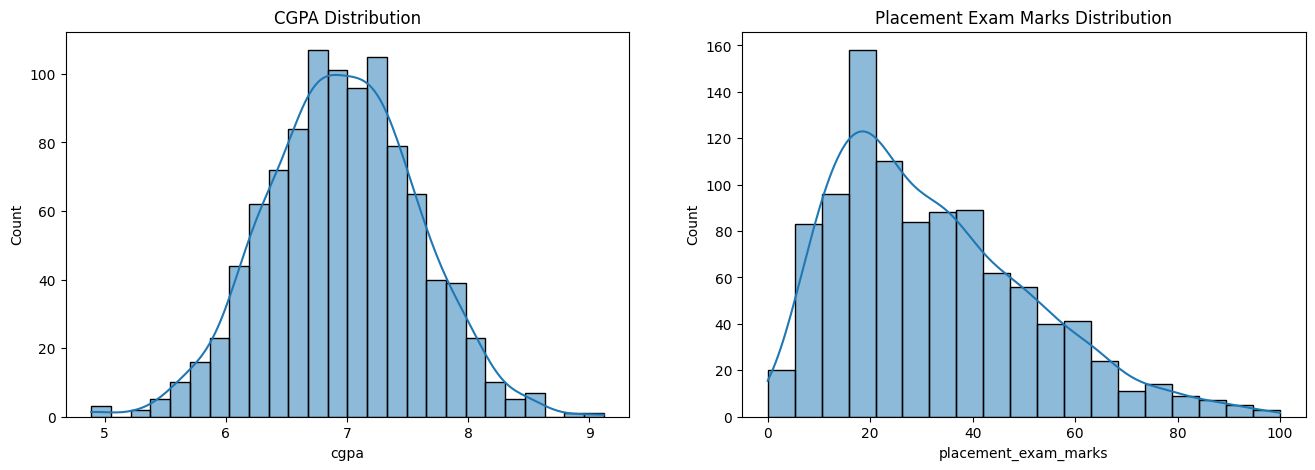

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [ ]:
# z- Score Technique is used when Data Distribution is Normal or Close to Normal
# Plot Data Distribution

plt.figure(figsize=(16,5))

# CGPA
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True) # kde=True adds the density line
plt.title('CGPA Distribution')

# Placement Exam Marks
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()

df['placement_exam_marks'].skew()

print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

In [4]:
# Finding the boundary values -> Apply Z Score on CGPA Column
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


Trimming

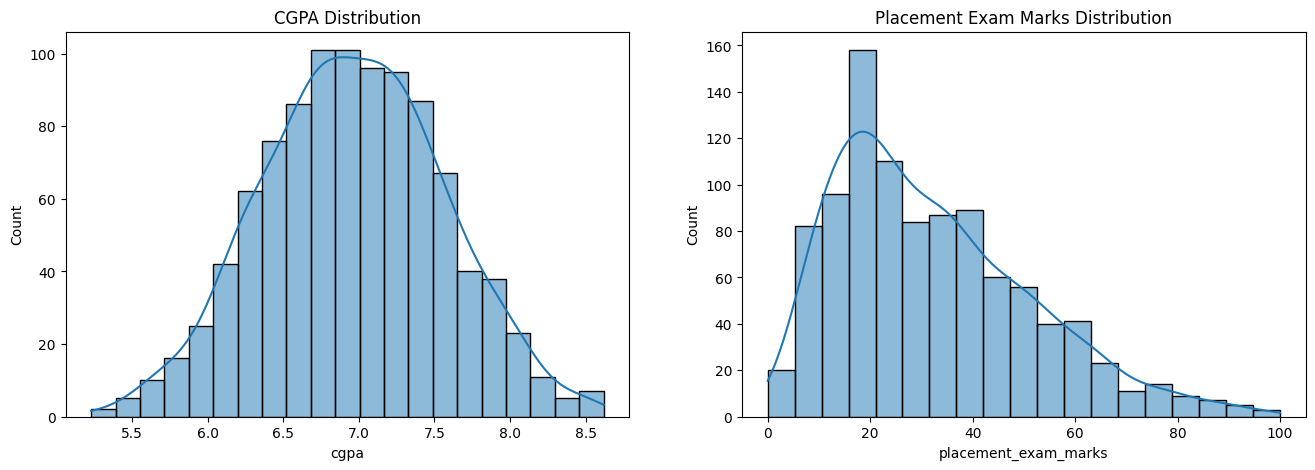

In [5]:
# direct Placement of Value
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

# Calculating the Zscore
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

# Trimming
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

plt.figure(figsize=(16,5))

# CGPA
plt.subplot(1,2,1)
sns.histplot(new_df['cgpa'], kde=True) # kde=True adds the density line
plt.title('CGPA Distribution')

# Placement Exam Marks
plt.subplot(1,2,2)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()

Capping

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64


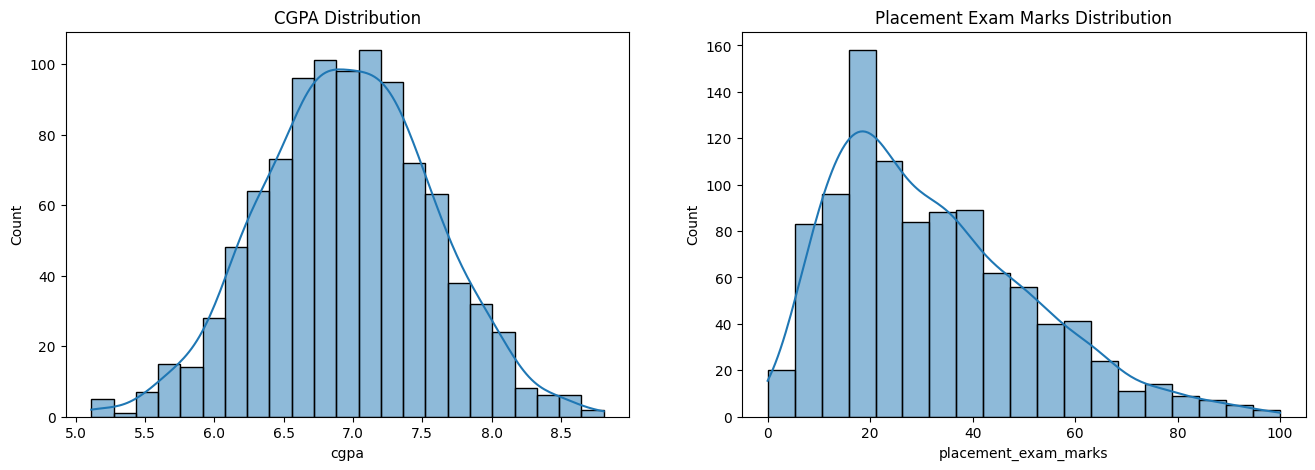

In [6]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

# Replace Outliers With UpperLimit and LowerLimit

df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

print(df['cgpa'].describe())

plt.figure(figsize=(16,5))

# CGPA
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True) # kde=True adds the density line
plt.title('CGPA Distribution')

# Placement Exam Marks
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()